In [161]:
import pandas as pd
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.arima import AutoARIMA
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_absolute_error

from sktime.forecasting.arima import AutoARIMA
from sktime.forecasting.compose import (TransformedTargetForecaster, make_reduction)
from sktime.forecasting.model_selection import (ExpandingWindowSplitter, ForecastingGridSearchCV)
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.transformations.series.detrend import Deseasonalizer, Detrender
from sktime.utils.plotting import plot_series
from pmdarima import AutoARIMA
from sklearn.preprocessing import StandardScaler

In [162]:
data = pd.read_csv('AirtrafficA4.csv')

# Data Cleaning and Formatting
invalid_month_rows = data[~data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]
data = data[data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]

# Remove commas from numeric fields and convert to float
data['TOTAL DEPARTURES'] = data['TOTAL DEPARTURES'].str.replace(',', '').astype(float)
data['HOURS FLOWN'] = data['HOURS FLOWN'].str.replace(',', '').astype(float)
data['KILOMETRE FLOWN'] = data['KILOMETRE FLOWN'].str.replace(',', '').astype(float)
data['PASSENGERS CARRIED'] = data['PASSENGERS CARRIED'].str.replace(',', '').astype(float)
data['AVAILABLE SEAT KILOMETRE (IN THOUSAND)'] = data['AVAILABLE SEAT KILOMETRE (IN THOUSAND)'].str.replace(',', '').astype(float)
data[' FREIGHT CARRIED (IN TONNE)'] = data[' FREIGHT CARRIED (IN TONNE)'].str.replace(',', '').astype(float)
data['MAIL CARRIED (IN TONNE)'] = data['MAIL CARRIED (IN TONNE)'].str.replace(',', '').astype(float)

# Create a Date column
data['DATE'] = pd.to_datetime(data['YEAR'].astype(str) + '-' + data['MONTH'], format='%Y-%b')
data = data.sort_values('DATE').set_index('DATE')

# Filter out the COVID-19 period (March 2020 - December 2021)
# data = data[(data.index < '2020-03-01') | (data.index > '2021-12-31')]



In [163]:
# Selecting the target variable 'PASSENGERS CARRIED'
y = data['PASSENGERS CARRIED']
y=y.dropna()
y_train, y_test = temporal_train_test_split(y, test_size=12)  # Use last 12 months as test set

In [164]:
import warnings
warnings.filterwarnings("ignore")
# Initialize and fit the AutoARIMA model on the entire dataset
forecaster = AutoARIMA(start_p=1, start_q=1, max_p=10, max_q=10, seasonal=True, suppress_warnings=True, stepwise=True)
forecaster.fit(y_train)

# Forecast from September 2023 to August 2024 (12 periods)
forecast_horizon = 12
forecast = forecaster.predict(forecast_horizon)

# Calculate MAPE for the test period
mape_value = MAPE(y_test, forecast)
print(f"MAPE on test set: {mape_value * 100:.3f}%")

MAPE on test set: 12.811%


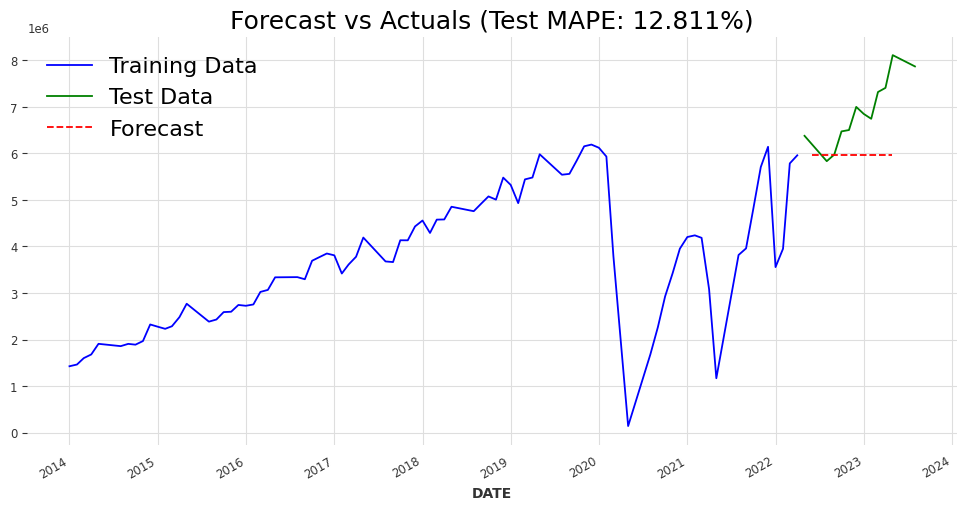

In [165]:
# Plotting the forecast alongside the training and test data
plt.figure(figsize=(12, 6))
plt.title(f"Forecast vs Actuals (Test MAPE: {mape_value * 100:.3f}%)", size=18)
y_train.plot(label="Training Data", color="blue")
y_test.plot(label="Test Data", color="green")
plt.plot(pd.date_range(start=y_test.index[0], periods=len(forecast), freq='M'), 
         forecast, label="Forecast", color="red", linestyle='--')
plt.legend(prop={"size": 16})
plt.show()

In [166]:
import warnings
warnings.filterwarnings("ignore")
# Initialize and fit the AutoARIMA model on the entire dataset
forecaster = AutoARIMA(start_p=1, start_q=1, max_p=10, max_q=10, seasonal=False, suppress_warnings=True, stepwise=True)
forecaster.fit(y)

# Forecast from September 2023 to August 2024 (12 periods)
forecast_horizon = 12
forecast = forecaster.predict(forecast_horizon)

# Generate dates for the forecast period
forecast_dates = pd.date_range(start='2023-09-01', periods=forecast_horizon, freq='MS')
forecast.index = forecast_dates

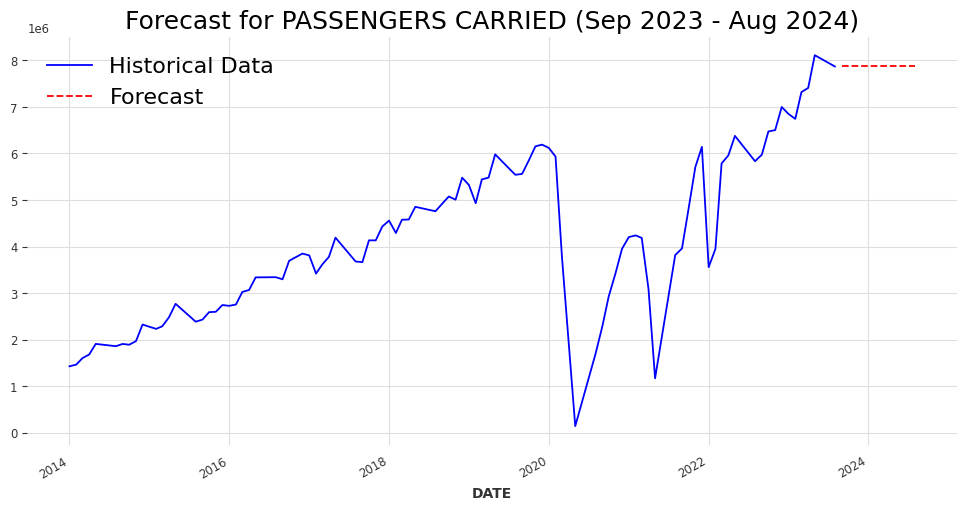

   YEAR_MONTH  PASSENGERS CARRIED
0    2023 SEP           7867259.0
1    2023 OCT           7867259.0
2    2023 NOV           7867259.0
3    2023 DEC           7867259.0
4    2024 JAN           7867259.0
5    2024 FEB           7867259.0
6    2024 MAR           7867259.0
7    2024 APR           7867259.0
8    2024 MAY           7867259.0
9    2024 JUN           7867259.0
10   2024 JUL           7867259.0
11   2024 AUG           7867259.0


In [167]:
# Plotting the forecast alongside the original series
plt.figure(figsize=(12, 6))
plt.title("Forecast for PASSENGERS CARRIED (Sep 2023 - Aug 2024)", size=18)
y.plot(label="Historical Data", color="blue")
forecast.plot(label="Forecast", color="red", linestyle='--')
plt.legend(prop={"size": 16})
plt.show()

# Prepare the forecast data for submission format
forecast_df = pd.DataFrame({'YEAR_MONTH': forecast.index.strftime('%Y %b').str.upper(), 'PASSENGERS CARRIED': forecast.values})
print(forecast_df)

# Save to CSV
forecast_df.to_csv('submission.csv', index=False)

In [168]:
# Prepare the target and features
y = data['PASSENGERS CARRIED']
train_size = len(y) - 12
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [169]:
# Fit the SARIMA model (adjust (p, d, q) and (P, D, Q, s) as needed)
model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit(disp=False)

# Forecast for the next 12 months
forecast = model_fit.forecast(steps=12)

# Calculate MAPE for the test period
mape_value = MAPE(y_test, forecast)
print(f"MAPE on test set: {mape_value * 100:.3f}%")

MAPE on test set: 11.019%


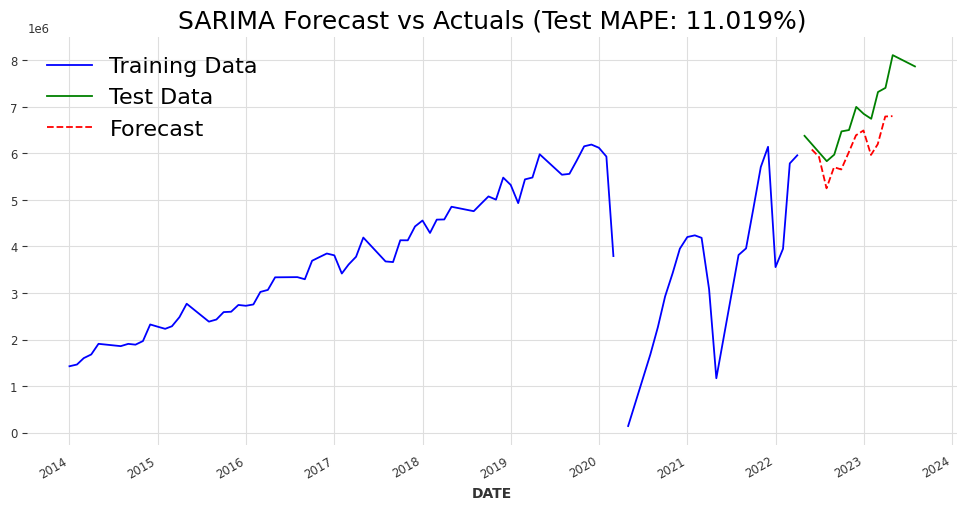

In [170]:
# Plotting the forecast alongside the training and test data
plt.figure(figsize=(12, 6))
plt.title(f"SARIMA Forecast vs Actuals (Test MAPE: {mape_value * 100:.3f}%)", size=18)
y_train.plot(label="Training Data", color="blue")
y_test.plot(label="Test Data", color="green")
plt.plot(pd.date_range(start=y_test.index[0], periods=len(forecast), freq='M'), 
         forecast, label="Forecast", color="red", linestyle='--')
plt.legend(prop={"size": 16})
plt.show()

In [171]:
# Fit the model on the full dataset for future predictions
full_model = SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
full_model_fit = full_model.fit(disp=False)

# Forecast for the desired period (Sep 2023 - Aug 2024)
full_forecast = full_model_fit.forecast(steps=12)

# Prepare the forecast data for submission format
forecast_dates = pd.date_range(start='2023-09-01', periods=12, freq='MS')
forecast_df = pd.DataFrame({'YEAR_MONTH': forecast_dates.strftime('%Y %b').str.upper(), 
                             'PASSENGERS CARRIED': full_forecast})
print(forecast_df)

# Save to CSV
forecast_df.to_csv('submission.csv', index=False)

    YEAR_MONTH  PASSENGERS CARRIED
96    2023 SEP        7.898054e+06
97    2023 OCT        7.546810e+06
98    2023 NOV        6.710114e+06
99    2023 DEC        7.040294e+06
100   2024 JAN        6.773127e+06
101   2024 FEB        7.241518e+06
102   2024 MAR        7.549063e+06
103   2024 APR        7.617440e+06
104   2024 MAY        7.227650e+06
105   2024 JUN        7.439454e+06
106   2024 JUL        8.079617e+06
107   2024 AUG        8.034313e+06
